In [ ]:

#Load the libraries
library("ecmwfr")
library(terra)
library(sf)
library(raster)

# set the key 
wf_set_key(key = "92995875-320a-4851-b78c-ddf26bc96cb4")

# Define years, months, and days
Year <- 2020:2021
Month <- sprintf("%02d", 1:12)  # Format months as "01" to "12"

# Define the request for ERA5 monthly averaged data
request <- list(
  dataset_short_name = "reanalysis-era5-land-monthly-means", # month
  product_type = "reanalysis",
  variable = "total_precipitation",
  year = Year,
  month = Month,
  time = "00:00",
  format = "netcdf",               
  area = c(20.0, 72.5, 7.5, 85.0),  #NWSE
  target = "era5-ppt.nc"         
)

# call:

save_path <- "D:/J"

file_1 <- wf_request(
  request  = request,  # the request
  transfer = TRUE,     # download the file
  path     = save_path      # store data in current working directory
)

unzip(file_1, exdir = save_path)
nc_files <- list.files(save_path, pattern = "\\.nc$", full.names = TRUE)

# Renombrar (si existe archivo .nc)
# Renombrar al nombre deseado
# Renombrar el archivo
if (length(nc_files) > 0) {
  old_name <- nc_files[1]
  new_name <- file.path(save_path, "era5-ppt.nc")
  if (file.rename(old_name, new_name)) {
    message("✅ Renombrado exitosamente.")
    
    # 🔄 Actualizar lista después de renombrar
    nc_files <- list.files(save_path, pattern = "\\.nc$", full.names = TRUE)
    print(nc_files)
  } else {
    warning("❌ Falló el renombrado.")
  }
}

#Open the NC file

tp_raster_stack <- brick(nc_files, varname="tp")

nlayers(tp_raster_stack)
plot(tp_raster_stack )

#Visualize the mean layer

mean_layer <- mean(tp_raster_stack , na.rm = TRUE)

# Plot the mean raster layer 
plot(mean_layer, main = "ERA-5 Reanalysis Data (total_precipitation 2020-21)")
     

# Add world map and shapefile layers
maps::map("world", add = TRUE)

### ############  DAILY DATA ERA5-LAND  ########################################

library("ecmwfr")
library(terra)
library(raster)
library(maps)
library(ncdf4)

# 1. Clave de API (solo una vez)
wf_set_key(key = "92995875-320a-4851-b78c-ddf26bc96cb4")

# 2. Crear función para descargar por año
descargar_precipitacion_diaria <- function(year) {
  request <- list(
    dataset_short_name = "reanalysis-era5-land", # daily
    product_type = "reanalysis",
    variable = "total_precipitation",
    year = as.character(year),
    month = sprintf("%02d", 1:12),
    day = sprintf("%02d", 1:31),
    time = "00:00",
    format = "netcdf",
    area = c(-0.1, -81.5, -19.0, -68.5),  # N, W, S, E (Perú)
    target = paste0("era5_tp_", year, ".nc")
  )
  
  # Descargar datos
  wf_request(
    user = "ecmwfr",         # Tu nombre de usuario CDS
    request = request,
    transfer = TRUE,
    path = "D:/J"
  )
}

# 3. Descargar de 1981 a 2024
years <- 1981:2024
lapply(years, descargar_precipitacion_diaria)

# Carpeta con los .zip
zip_folder <- "D:/J/era5-land-mmday"

# Listar todos los archivos .zip
zip_files <- list.files(zip_folder, pattern = "\\.zip$", full.names = TRUE)

# Función para descomprimir y renombrar .nc
descomprimir_y_renombrar <- function(zip_path) {
  # Carpeta destino
  output_dir <- dirname(zip_path)
  
  # Nombre base del .zip sin extensión
  zip_base <- tools::file_path_sans_ext(basename(zip_path))
  
  # Descomprimir temporalmente
  temp_files <- unzip(zip_path, exdir = output_dir)
  
  # Encontrar el .nc extraído (ej. "data_0.nc")
  nc_file <- temp_files[grepl("\\.nc$", temp_files)]
  
  # Nuevo nombre: el mismo que el .zip pero con extensión .nc
  new_nc_path <- file.path(output_dir, paste0(zip_base, ".nc"))
  
  # Renombrar
  file.rename(nc_file, new_nc_path)
  
  return(new_nc_path)
}

# Ejecutar para todos
resultados <- lapply(zip_files, descomprimir_y_renombrar)

cat("✅ Archivos extraídos y renombrados correctamente.\n")


# Leer archivo descargado
nc_path <- "D:/J//era5-land-mmday/era5_tp_2024.nc"
r <- brick(nc_path, varname = "tp")

# Convertir de metros a milímetros
r_mm_day <- r * 1000

# Guardar como nuevo archivo in mm day
writeRaster(r_mm_day, filename = "D:/J/era5-land-mmday/era5mmday-2024.nc", format = "CDF", varname = "ppt", overwrite = TRUE)

#PLOT

tp_raster_stack <- brick("D:/J/era5-land-mmday/era5mmday-2007.nc", varname = "ppt")

mean_layer <- mean(tp_raster_stack , na.rm = TRUE)

# Plot the mean raster layer 
plot(mean_layer, main = "ERA-5 Reanalysis Data (total_precipitation 2020-21)")

# Add world map and shapefile layers
maps::map("world", add = TRUE)


library(ecmwfr)

# Asegurar que la carpeta exista
if(!dir.exists("D:/J/TCWV")) dir.create("D:/J/TCWV", recursive = TRUE)

descargar_cape_era5 <- function(year) {
  
  request <- list(
    dataset_short_name = "reanalysis-era5-single-levels",
    product_type       = "reanalysis",
    variable           = "total_column_water_vapour",#total_column_water_vapour convective_available_potential_energy
    year               = as.character(year),
    month              = sprintf("%02d", 1:12),
    day                = sprintf("%02d", 1:31),
    time               = "00:00", 
    format             = "netcdf",
    area               = c(-0.1, -81.5, -19.0, -68.5), # Cobertura Perú
    target             = paste0("era5_tcwv_", year, ".nc")
  )
  
  # Usamos tryCatch para evitar que el bucle se rompa
  tryCatch({
    wf_request(
      user     = "ecmwfr", 
      request  = request,
      transfer = TRUE,
      path     = "D:/J/TCWV",
      verbose  = TRUE
    )
    cat("\n✔ ¡Éxito! Archivo guardado para el año:", year, "\n")
  }, error = function(e) {
    cat("\n✘ Error detectado en el año", year, ":", e$message, "\n")
  })
}

# Ejecutar el bucle para tu rango de interés
años_estudio <- 1981:2024

for(anio in años_estudio) {
  cat("\n******************************************")
  cat("\nIniciando proceso para:", anio)
  descargar_cape_era5(anio)
}


library(terra)
library(ncdf4)

# Abrir el archivo
nc_data <- nc_open("D:/J/CAPE/era5_cape_2000.nc")

# Listar los nombres de todas las variables disponibles
nombres_vars <- names(nc_data$var)
print(nombres_vars)

r_cape <- rast("D:/J/CAPE/era5_cape_2000.nc")
capa_ejemplo <- r_cape[[1]]

# 3. Ploteo básico
plot(capa_ejemplo, 
     main = "CAPE en el Perú (J/kg) - Enero 2000",
     col = rev(terrain.colors(50)), # Escala de colores tipo terreno
     plg = list(title = "J/kg"))
# Cerrar el archivo después de inspeccionar
nc_close(nc_data)
# 1. Listar todos los archivos descargados
archivos <- list.files("D:/J/CAPE", pattern = "era5_cape_.*\\.nc$", full.names = TRUE)

# 2. Cargar todos los años como un solo objeto (SpatRaster)
# terra manejará la unión temporal automáticamente
cape_total <- rast(archivos)

# 3. Guardar como un único archivo NetCDF
writeCDF(cape_total, 
         filename = "D:/J/CAPE/cape_1981_2024.nc", 
         overwrite = TRUE, 
         varname = "cape", 
         unit = "J/kg", 
         longname = "Convective Available Potential Energy")

cat("✔ Archivo consolidado creado con éxito.")


#============================================================================
  # 3. FUNCIÓN PARA DESCARGAR VIENTO (componentes u10 y v10 a 10m)
  # ============================================================================
descargar_vientov_era5 <- function(year) {
  # Crear carpeta si no existe
  if(!dir.exists("D:/J/WINDv")) dir.create("D:/J/WINDv", recursive = TRUE)
  
  request <- list(
    dataset_short_name = "reanalysis-era5-single-levels",
    product_type       = "reanalysis",
    variable           = c("10m_v_component_of_wind"), # , "10m_v_component_of_wind"
    year               = as.character(year),
    month              = sprintf("%02d", 1:12),
    day                = sprintf("%02d", 1:31),
    time               = "00:00", 
    format             = "netcdf",
    area               = c(-0.1, -81.5, -19.0, -68.5),
    target             = paste0("era5_windv_", year, ".nc")
  )
  
  tryCatch({
    wf_request(user = "ecmwfr", request = request, transfer = TRUE, path = "D:/J/WINDv", verbose = TRUE)
    cat("\n✔ Viento descargado para año:", year, "\n")
  }, error = function(e) {
    cat("\n✘ Error en Viento año", year, ":", e$message, "\n")
  })
}

# ============================================================================
# 4. EJECUTAR DESCARGAS PARA TODOS LOS AÑOS
# ============================================================================
years <- 20:2024

#cat("\n========== DESCARGANDO VIENTO (u10 + v10) ==========\n")
for(yr in years) descargar_vientov_era5(yr)

cat("\n========== ¡DESCARGA COMPLETADA! ==========\n")

# Leer archivo de un año
r_wind <- rast("D:/J/WIND/era5_wind_2024.nc")

# Extraer componentes
u <- r_wind[[grep("u10", names(r_wind))]]
v <- r_wind[[grep("v10", names(r_wind))]]

# Velocidad del viento (m/s)
wind_speed <- sqrt(u^2 + v^2)

# Guardar
writeRaster(wind_speed, "D:/J/WIND/era5_windspeed_2024.nc", overwrite = TRUE)



### ############  DAILY Tmax AND Tmin FROM ERA5 (0.25° ~ 28 km)  #################
### ############  Tmax/Tmin DIARIAS CON ERA5-LAND  ###############################

### ############  TMIX/TMIN CON ESTADÍSTICAS DIARIAS OFICIALES  ##################
library(ecmwfr)
library(terra)

wf_set_key(key = "92995875-320a-4851-b78c-ddf26bc96cb4")

descargar_tmax_tmin_anual <- function(year) {
  if(!dir.exists("D:/J/TEMP_DAILY_ERA5")) dir.create("D:/J/TEMP_DAILY_ERA5", recursive = TRUE)
  
  request <- list(
    dataset_short_name = "derived-era5-single-levels-daily-statistics",
    variable           = "2m_temperature",
    year               = as.character(year),
    month              = sprintf("%02d", 1:12),     # ← Solicita todos los meses
    day                = sprintf("%02d", 1:31),     # ← Todos los días
    daily_statistic    = c("daily_maximum"), # , "daily_minimum"
    time_zone          = "utc-05:00",
    format             = "netcdf",
    area               = c(-0.1, -81.5, -19.0, -68.5),
    target             = paste0("era5_daily_temp_", year, ".nc")
  )
  
  tryCatch({
    cat("\n=== Descargando Tmax/Tmin diarias para año:", year, "===\n")
    wf_request(
      user = "ecmwfr", 
      request = request, 
      transfer = TRUE, 
      path = "D:/J/TEMP_DAILY_ERA5", 
      verbose = TRUE, 
      time_out = 3600
    )
    
    # Convertir a Celsius automáticamente
    r <- rast(paste0("D:/J/TEMP_DAILY_ERA5/era5_daily_temp_", year, ".nc")) - 273.15
    writeRaster(r, paste0("D:/J/TEMP_DAILY_ERA5/era5_daily_temp_", year, "_celsius.nc"), overwrite = TRUE)
    cat("\n✔ Archivo guardado y convertido a Celsius para año:", year, "\n")
    
  }, error = function(e) {
    cat("\n✘ Error en año", year, ":", e$message, "\n")
  })
}

# Descargar años
years <- 1981:2024
for(yr in years) descargar_tmax_tmin_anual(yr)


library(ecmwfr)
library(terra)

wf_set_key(key = "92995875-320a-4851-b78c-ddf26bc96cb4")

# ============================================================================
# DESCARGAR SOLO TMAX (en Kelvin)
# ============================================================================
descargar_tmax_anual <- function(year) {
  if(!dir.exists("D:/J/TMAX_ERA5")) dir.create("D:/J/TMAX_ERA5", recursive = TRUE)
  
  request <- list(
    dataset_short_name = "derived-era5-single-levels-daily-statistics",
    variable           = "2m_temperature",
    year               = as.character(year),
    month              = sprintf("%02d", 1:12),
    day                = sprintf("%02d", 1:31),
    daily_statistic    = "daily_maximum",  # Solo Tmax
    time_zone          = "utc-05:00",
    format             = "netcdf",
    area               = c(-0.1, -81.5, -19.0, -68.5),
    target             = paste0("era5_tmax_", year, ".nc")
  )
  
  tryCatch({
    cat("\n=== Descargando TMAX para año:", year, "===\n")
    wf_request(
      user = "ecmwfr", 
      request = request, 
      transfer = TRUE, 
      path = "D:/J/TMAX_ERA5", 
      verbose = TRUE, 
      time_out = 3600
    )
    cat("\n✔ TMAX descargado para año:", year, "\n")
    
  }, error = function(e) {
    cat("\n✘ Error en TMAX año", year, ":", e$message, "\n")
  })
}

# ============================================================================
# DESCARGAR SOLO TMIN (en Kelvin)
# ============================================================================
descargar_tmin_anual <- function(year) {
  if(!dir.exists("D:/J/TMIN_ERA5")) dir.create("D:/J/TMIN_ERA5", recursive = TRUE)
  
  request <- list(
    dataset_short_name = "derived-era5-single-levels-daily-statistics",
    variable           = "2m_temperature",
    year               = as.character(year),
    month              = sprintf("%02d", 1:12),
    day                = sprintf("%02d", 1:31),
    daily_statistic    = "daily_minimum",  # Solo Tmin
    time_zone          = "utc-05:00",
    format             = "netcdf",
    area               = c(-0.1, -81.5, -19.0, -68.5),
    target             = paste0("era5_tmin_", year, ".nc")
  )
  
  tryCatch({
    cat("\n=== Descargando TMIN para año:", year, "===\n")
    wf_request(
      user = "ecmwfr", 
      request = request, 
      transfer = TRUE, 
      path = "D:/J/TMIN_ERA5", 
      verbose = TRUE, 
      time_out = 3600
    )
    cat("\n✔ TMIN descargado para año:", year, "\n")
    
  }, error = function(e) {
    cat("\n✘ Error en TMIN año", year, ":", e$message, "\n")
  })
}

# ============================================================================
# EJECUTAR (prueba con un año primero)
# ============================================================================
years <- 1983:2024  # Prueba solo 1981 primero

# Descargar TMAX
for(yr in years) descargar_tmax_anual(yr)

# Descargar TMIN
for(yr in years) descargar_tmin_anual(yr)

# Si funciona, descargar todos:
# years <- 1981:2024
# for(yr in years) descargar_tmax_anual(yr)
# for(yr in years) descargar_tmin_anual(yr)



### ############  DAILY SOIL MOISTURE (SWVL1) - ERA5-LAND  ####################

library("ecmwfr")
library(terra)
library(raster)
library(maps)
library(ncdf4)

# 1. Clave de API (solo una vez)
wf_set_key(key = "92995875-320a-4851-b78c-ddf26bc96cb4")

# 2. Crear función para descargar humedad del suelo por año
descargar_swvl1_diaria <- function(year) {
  
  # Crear directorio si no existe
  if(!dir.exists("D:/J/SOIL_MOISTURE_ERA5")) {
    dir.create("D:/J/SOIL_MOISTURE_ERA5", recursive = TRUE)
  }
  
  request <- list(
    dataset_short_name = "reanalysis-era5-land",  # Datos diarios
    product_type = "reanalysis",
    variable = "volumetric_soil_water_layer_1",   # Humedad del suelo 0-7 cm
    year = as.character(year),
    month = sprintf("%02d", 1:12),
    day = sprintf("%02d", 1:31),
    time = "00:00",                               # Un solo tiempo por día
    format = "netcdf",
    area = c(-0.1, -81.5, -19.0, -68.5),          # N, W, S, E (Perú)
    target = paste0("era5_swvl1_", year, ".nc")
  )
  
  # Descargar datos
  tryCatch({
    cat("\n=== Descargando SWVL1 para año:", year, "===\n")
    wf_request(
      user = "ecmwfr",
      request = request,
      transfer = TRUE,
      path = "D:/J/SOIL_MOISTURE_ERA5",
      verbose = TRUE,
      time_out = 3600
    )
    cat("\n✔ SWVL1 descargado para año:", year, "\n")
    
  }, error = function(e) {
    cat("\n✘ Error en SWVL1 año", year, ":", e$message, "\n")
  })
}

# 3. Descargar de 1981 a 2024
years <- 1981:2024
for(yr in years) {
  descargar_swvl1_diaria(yr)
}

# 4. Verificar archivos descargados
cat("\n=== Archivos descargados ===\n")
list.files("D:/J/SOIL_MOISTURE_ERA5", pattern = "*.nc")


# Carpeta con los .zip
zip_folder <- "D:/J/SOIL_MOISTURE_ERA5"

# Listar todos los archivos .zip
zip_files <- list.files(zip_folder, pattern = "\\.zip$", full.names = TRUE)

# Función para descomprimir y renombrar .nc
descomprimir_y_renombrar <- function(zip_path) {
  # Carpeta destino
  output_dir <- dirname(zip_path)
  
  # Nombre base del .zip sin extensión
  zip_base <- tools::file_path_sans_ext(basename(zip_path))
  
  # Descomprimir temporalmente
  temp_files <- unzip(zip_path, exdir = output_dir)
  
  # Encontrar el .nc extraído (ej. "data_0.nc")
  nc_file <- temp_files[grepl("\\.nc$", temp_files)]
  
  # Nuevo nombre: el mismo que el .zip pero con extensión .nc
  new_nc_path <- file.path(output_dir, paste0(zip_base, ".nc"))
  
  # Renombrar
  file.rename(nc_file, new_nc_path)
  
  return(new_nc_path)
}

# Ejecutar para todos
resultados <- lapply(zip_files, descomprimir_y_renombrar)


# Ahora leer un archivo de humedad (ejemplo: año 2024)
nc_path <- "D:/J/SOIL_MOISTURE_ERA5/era5_swvl1_1981.nc"

# Leer con raster (variable = "swvl1")
r <- brick(nc_path, varname = "swvl1")

# Verificar
print(r)
plot(r, 1)  # primer día


In [ ]:
library(blockCV)
library(sf) # working with spatial vector data
library(terra) # working with spatial raster data
library(tmap) # plotting maps

# 1. Rutas y archivos
input_path <- "D:/R/RFSI paper/BlockVC/raster/"
output_path <- "D:/R/RFSI paper/BlockVC/raster_5km/" # Carpeta nueva para no sobreescribir
if (!dir.exists(output_path)) dir.create(output_path)

files <- list.files(input_path, pattern = "\\.tif$", full.names = TRUE)
files_static <- files[grep("dem|slope|cos|sin|twi", files)]
ref_5km <- rast(paste0(input_path, "precland.tif"))

# 2. Procesar, Resamplear con AVERAGE y Guardar
static_list <- lapply(files_static, function(x) {
  r <- rast(x)
  nombre_archivo <- basename(x)
  
  # Si la geometría no coincide, resampleamos
  if (!compareGeom(r, ref_5km, stopOnError = FALSE)) {
    cat("Resampleando (average):", nombre_archivo, "\n")
    
    # IMPORTANTE: Usamos method = 'average' para conservar la masa/promedio
    r_5km <- resample(r, ref_5km, method = "average")
    
    # 3. Guardar el archivo físicamente
    writeRaster(r_5km, 
                filename = paste0(output_path, gsub(".tif", "_5km.tif", nombre_archivo)), 
                overwrite = TRUE)
    
    return(r_5km)
  } else {
    return(r)
  }
})

In [1]:
import xarray as xr
import pandas as pd
import os

# Carpetas
input_folder = r"D:/J/SOIL_MOISTURE_ERA5"
output_folder = r"D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Listar archivos .nc que empiecen con "era5_swvl1_"
nc_files = [f for f in os.listdir(input_folder) if f.startswith("era5_swvl1_") and f.endswith(".nc")]

for nc_file in nc_files:
    try:
        # Extraer año (asumiendo era5_swvl1_YYYY.nc)
        parts = nc_file.split("_")
        year = int(parts[2].replace(".nc", ""))
        
        print(f"📂 Procesando: {nc_file} (Año {year})")
        ds_path = os.path.join(input_folder, nc_file)
        ds = xr.open_dataset(ds_path)

        # Identificar la dimensión temporal entre las posibilidades
        dim_actual = None
        for nombre in ['valid_time', 'time', 'forecast_time']:  # Añadir 'forecast_time' por si acaso
            if nombre in ds.dims:
                dim_actual = nombre
                break

        if dim_actual:
            # 1. Número de pasos temporales (días)
            n_steps = ds.dims[dim_actual]
            
            # 2. Crear las fechas reales para ese año (diarias)
            #    Ajusta automáticamente años bisiestos
            time_coords = pd.date_range(start=f"{year}-01-01", periods=n_steps, freq="D")

            # 3. Renombrar la dimensión a 'time' (estándar)
            ds = ds.rename({dim_actual: "time"})
            
            # 4. Asignar las coordenadas de tiempo reales
            ds = ds.assign_coords(time=time_coords)

            # 5. (Opcional) Renombrar la variable a algo más corto si quieres
            #    Pero ya se llama 'swvl1', así que lo dejamos.

            # 6. Guardar el archivo corregido
            output_path = os.path.join(output_folder, f"swvl1-{year}-daily.nc")
            ds.to_netcdf(output_path)
            print(f"✅ ¡Corregido!: {output_path}")
        else:
            print(f"❌ Dimensiones no reconocidas en {nc_file}: {list(ds.dims)}")
            
    except Exception as e:
        print(f"❌ Error crítico en {nc_file}: {e}")

print("🎉 ¡Todo el dataset de humedad del suelo ha sido estandarizado!")

📂 Procesando: era5_swvl1_1981.nc (Año 1981)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19408\3868561868.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_steps = ds.dims[dim_actual]


✅ ¡Corregido!: D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\swvl1-1981-daily.nc
📂 Procesando: era5_swvl1_1982.nc (Año 1982)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19408\3868561868.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_steps = ds.dims[dim_actual]


✅ ¡Corregido!: D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\swvl1-1982-daily.nc
📂 Procesando: era5_swvl1_1983.nc (Año 1983)


...

✅ ¡Corregido!: D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\swvl1-2022-daily.nc
📂 Procesando: era5_swvl1_2023.nc (Año 2023)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19408\3868561868.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_steps = ds.dims[dim_actual]


✅ ¡Corregido!: D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\swvl1-2023-daily.nc
📂 Procesando: era5_swvl1_2024.nc (Año 2024)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19408\3868561868.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_steps = ds.dims[dim_actual]


✅ ¡Corregido!: D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\swvl1-2024-daily.nc
🎉 ¡Todo el dataset de humedad del suelo ha sido estandarizado!


In [2]:
import xarray as xr
import pandas as pd
import os
import glob
folder_path= "D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED/"

In [3]:
# Find all netcdf4 files in the folder
file_list = glob.glob(folder_path + "*.nc")
file_list

['D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1981-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1982-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1983-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1984-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1985-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1986-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1987-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1988-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1989-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1990-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1991-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1992-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1993-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1994-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1995-daily.nc',
 'D:/J/SOIL_MOISTURE_ERA5/STANDARDIZED\\swvl1-1996-daily.nc',
 'D:/J/S

In [4]:
#load all netcdf files in the folder and combine them by time
ds = xr.open_mfdataset(file_list, combine = "nested", concat_dim = "time")
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 16071, latitude: 190, longitude: 131)
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 2kB -0.1 -0.2 -0.3 -0.4 ... -18.8 -18.9 -19.0
  * longitude  (longitude) float64 1kB -81.5 -81.4 -81.3 ... -68.7 -68.6 -68.5
    expver     (time) <U4 257kB dask.array<chunksize=(365,), meta=np.ndarray>
  * time       (time) datetime64[ns] 129kB 1981-01-01 1981-01-02 ... 2024-12-31
Data variables:
    swvl1      (time, latitude, longitude) float32 2GB dask.array<chunksize=(183, 95, 66), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-04T23:12 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
ds.to_netcdf("D:/J/SOIL_MOISTURE_ERA5/SOILMOISTURE.nc")
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 16071, latitude: 190, longitude: 131)
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 2kB -0.1 -0.2 -0.3 -0.4 ... -18.8 -18.9 -19.0
  * longitude  (longitude) float64 1kB -81.5 -81.4 -81.3 ... -68.7 -68.6 -68.5
    expver     (time) <U4 257kB dask.array<chunksize=(365,), meta=np.ndarray>
  * time       (time) datetime64[ns] 129kB 1981-01-01 1981-01-02 ... 2024-12-31
Data variables:
    swvl1      (time, latitude, longitude) float32 2GB dask.array<chunksize=(183, 95, 66), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-04T23:12 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
import xarray as xr    ##  okkkk
import numpy as np

input_path = "D:/J/SOIL_MOISTURE_ERA5/SOILMOISTURE.nc"
output_path = "D:/J/SOIL_MOISTURE_ERA5/SOILMOISTUREPERU.nc"

# 1. Abrir dataset
ds = xr.open_dataset(input_path)

# 2. Renombrar coordenadas (igual que en TCWV)
ds = ds.rename({
    'latitude': 'lat',
    'longitude': 'lon'
})

# 3. Asegurar orden de lat (Norte a Sur)
if ds['lat'][0] < ds['lat'][-1]:
    ds = ds.reindex(lat=ds.lat[::-1])

# 4. Transponer la variable principal al orden (time, lat, lon)
#    ¡Cambio clave: swvl1 en lugar de tcwv!
if 'swvl1' in ds:
    ds['swvl1'] = ds['swvl1'].transpose('time', 'lat', 'lon')
else:
    print("⚠️ Variable 'swvl1' no encontrada. Revisa el nombre.")

# 5. Atributos CF estándar (igual)
ds['lat'].attrs = {
    'units': 'degrees_north',
    'long_name': 'latitude',
    'standard_name': 'latitude'
}
ds['lon'].attrs = {
    'units': 'degrees_east',
    'long_name': 'longitude',
    'standard_name': 'longitude'
}
ds['time'].attrs = {
    'long_name': 'time',
    'standard_name': 'time'
}
# Unidades correctas para humedad del suelo
ds['swvl1'].attrs['units'] = 'm3 m-3'
ds['swvl1'].attrs['long_name'] = 'Volumetric soil water layer 1'

# 6. 🆕 Eliminar coordenadas extra que molestan a ArcGIS
if 'expver' in ds.coords:
    ds = ds.drop_vars('expver')
if 'number' in ds.coords:
    ds = ds.drop_vars('number')

# 7. Guardar NetCDF compatible con ArcGIS
ds.to_netcdf(output_path)

print(f"✅ Archivo preparado para ArcGIS: {output_path}")

✅ Archivo preparado para ArcGIS: D:/J/SOIL_MOISTURE_ERA5/SOILMOISTUREPERU.nc


In [27]:
import xarray as xr
import rioxarray
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio.transform import from_bounds

# Abrir dataset y asignar CRS
ds = xr.open_dataset("D:/R//LANDPERU7km.nc")#RAINday = xr.open_dataset("D:/R//LANDPERU7km.nc") D:/J/SOIL_MOISTURE_ERA5/SOILMOISTUREPERU.nc
ds = ds.rio.write_crs(4326) # "D:/R/RFSI paper/BlockVC/raster_5km/tmax_daily_1981_2020_005.nc"   "D:/J/CAPE/CAPEPER/CAPEPERU.nc"
ds 

<xarray.Dataset> Size: 2GB
Dimensions:  (lon: 131, lat: 190, time: 16071)
Coordinates:
    crs      int64 8B 0
  * lon      (lon) float64 1kB -81.5 -81.4 -81.3 -81.2 ... -68.7 -68.6 -68.5
  * lat      (lat) float64 2kB -0.1 -0.2 -0.3 -0.4 ... -18.7 -18.8 -18.9 -19.0
  * time     (time) datetime64[ns] 129kB 1981-01-01 1981-01-02 ... 2024-12-31
Data variables:
    ppt      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:  CF-1.4
    created_by:   R, packages ncdf4 and raster (version 3.6-30)
    date:         2025-07-23 23:05:08

In [22]:
des_gdf = gpd.GeoDataFrame.from_file('D:/S/Serbia1km/Interpolation/Titicaca_border/watershed.shp')
des_gdf.head()

,gid,geometry
0,0,"POLYGON ((-76.47792 -10.68208, -76.47542 -10.6..."


In [23]:
deschutes_ds = ds['tmin'].sel(time=slice("2000-01-01", "2017-12-31")).rio.clip(des_gdf.geometry, des_gdf.crs)

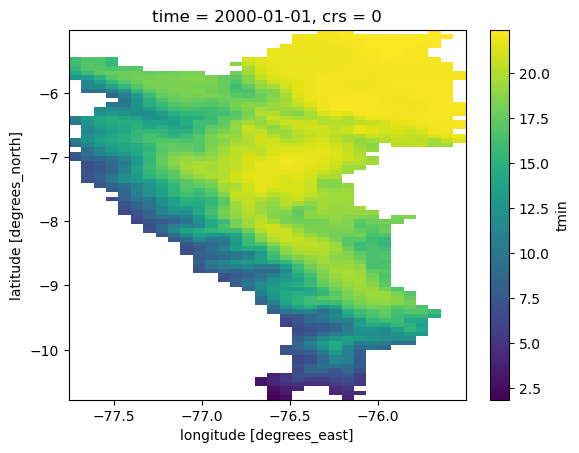

In [24]:
# Definir nueva resolución (0.07 grados ~ 7 km)
nueva_resolucion = 0.07

# Calcular límites del raster recortado
bounds = deschutes_ds.rio.bounds()

# Calcular nuevo ancho y alto basado en la nueva resolución
width = int((bounds[2] - bounds[0]) / nueva_resolucion)
height = int((bounds[3] - bounds[1]) / nueva_resolucion)

# Crear nueva transformada con la resolución deseada
nuevo_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

# Reproyectar con interpolación bilineal
deschutes_resampled = deschutes_ds.rio.reproject(
    dst_crs=deschutes_ds.rio.crs,
    shape=(height, width),
    transform=nuevo_transform,
    resampling=Resampling.bilinear
)

deschutes_resampled .isel(time=0).plot()

In [25]:
# Guardar en formato GeoTIFF
deschutes_resampled.rio.to_raster('D:/R/RFSI paper/BlockVC/raster_7km/tmin_2000_2017.tif')

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# 1. Rutas de los archivos
csv_path = r'D:\R\RFSI paper\completed_daily_dataset.csv'
shp_path = r'D:\R\RFSI paper\BlockVC\Shp\watershed.shp'

# 2. Cargar el archivo SHP de la cuenca
cuenca = gpd.read_file(shp_path)

# 3. Cargar el CSV con los datos diarios
# Asumimos que el CSV usa comas como separador
df = pd.read_csv(csv_path)

# 4. Convertir el DataFrame de estaciones en un GeoDataFrame
# Usamos las columnas 'x' e 'y' que se ven en tu imagen
geometry = [Point(xy) for xy in zip(df['x'], df['y'])]
gdf_estaciones = gpd.GeoDataFrame(df, geometry=geometry)

# 5. Asegurar que ambos archivos tengan el mismo sistema de coordenadas (CRS)
# Generalmente PISCO/SENAMHI usan WGS84 (EPSG:4326)
if gdf_estaciones.crs is None:
    gdf_estaciones.set_crs(epsg=4326, inplace=True)

if cuenca.crs != gdf_estaciones.crs:
    cuenca = cuenca.to_crs(gdf_estaciones.crs)

# 6. Realizar el recorte espacial (Spatial Join)
# Esto selecciona solo las estaciones que están "dentro" del polígono de la cuenca
estaciones_cuenca = gpd.sjoin(gdf_estaciones, cuenca, predicate='within')

# 7. Limpiar y guardar el resultado
# Eliminamos la columna geometry y las columnas extras del join si prefieres un CSV limpio
df_final = pd.DataFrame(estaciones_cuenca.drop(columns=['geometry', 'index_right']))

output_path = r'D:\R\RFSI paper\estaciones_huallaga2.csv'
df_final.to_csv(output_path, index=False)

print(f"Proceso terminado. Se extrajeron {len(df_final)} estaciones para la cuenca.")
print(f"Archivo guardado en: {output_path}")

In [6]:
import pandas as pd
import geopandas as gpd
import rasterio # Necesitas instalarlo: pip install rasterio
from shapely.geometry import Point

# 1. Cargar tus estaciones filtradas de la cuenca
csv_path = r'D:\R\RFSI paper\estaciones_huallaga.csv'
df = pd.read_csv(csv_path)

# Convertir a GeoDataFrame (asumiendo que x e y en el CSV son WGS84)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs="EPSG:4326")

# 2. Lista de tus archivos raster estáticos (¡Agregado el SD de 5km!)
static_files = {
    'elevation': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/dem_utm.tif', 
    'slope': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/slope_utm.tif',
    'aspect_cos': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/cos_utm.tif',
    'aspect_sin': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/sin_utm.tif',
    'twi': r'D:/S/Serbia1km/Interpolation/Huallaga/variabl_utm/twi_utm.tif',
    # NUEVO: Ruta al raster de desviación estándar de 5km que creaste en R
    'sd_dem_7km': r'D:/R/RFSI paper/BlockVC/raster_7kmv2/dem_sd_7km.tif',
    'av_dem_7km': r'D:/R/RFSI paper/BlockVC/raster_7kmv2/dem_7km.tif'
}

# 3. Función de extracción
def extract_from_raster(gdf_points, raster_path, column_name):
    with rasterio.open(raster_path) as src:
        # IMPORTANTE: Reproyectar los puntos al CRS del Raster (UTM) para que coincidan
        points_utm = gdf_points.to_crs(src.crs)
        coords = [(pt.x, pt.y) for pt in points_utm.geometry]
        
        # Extraer los valores del raster en esas coordenadas
        gdf_points[column_name] = [val[0] for val in src.sample(coords)]
    return gdf_points

# 4. Correr la extracción para cada archivo (incluyendo el nuevo sd_dem_5km)
for var_name, path in static_files.items():
    print(f"Extrayendo valores de: {var_name}")
    gdf = extract_from_raster(gdf, path, var_name)

# ==============================================================================
# 5. NUEVO: Crear la columna de la diferencia física para las estaciones
# (Elevación de alta resolución original - Desviación Estándar de 5km)
# ==============================================================================
print("Calculando la diferencia: dem_90m - sd_7km_dem...")
gdf['dem_minus_sd7km'] = gdf['elevation'] - gdf['sd_dem_7km']
gdf['dem_minus_av7km'] = gdf['elevation'] - gdf['av_dem_7km']

# 6. Guardar el resultado en un nuevo CSV
# Eliminamos la columna 'geometry' para que sea un CSV normal
df_final = pd.DataFrame(gdf.drop(columns='geometry'))
final_output = r'D:\R\RFSI paper\dataset_huallaga_ready1.csv'
df_final.to_csv(final_output, index=False)

print(f"Proceso completado. Archivo final guardado en: {final_output}")

Extrayendo valores de: elevation
Extrayendo valores de: slope
Extrayendo valores de: aspect_cos
Extrayendo valores de: aspect_sin
Extrayendo valores de: twi
Extrayendo valores de: sd_dem_7km
Extrayendo valores de: av_dem_7km
Calculando la diferencia: dem_90m - sd_7km_dem...
Proceso completado. Archivo final guardado en: D:\R\RFSI paper\dataset_huallaga_ready1.csv


In [7]:
df_final

,name,x,y,1981-01,1981-01.1,1981-01.2,1981-01.3,1981-01.4,1981-01.5,1981-01.6,...,gid,elevation,slope,aspect_cos,aspect_sin,twi,sd_dem_7km,av_dem_7km,dem_minus_sd7km,dem_minus_av7km
0,Station-015,-76.77944,-6.915000,0.000,0.000,0.000000,0.000,0.000,0.000000,19.500000,...,0,317,0.038637,-0.316228,-0.948683,6.676572,185.203674,478.776001,131.796326,-161.776001
1,Station-029,-76.32194,-6.593056,0.000,0.000,0.000000,0.000,0.000,0.900000,11.400000,...,0,206,0.054310,-0.974391,-0.224859,8.415027,106.180008,313.560272,99.819992,-107.560272
2,Station-050,-77.16694,-6.046667,0.000,0.000,0.000000,0.000,0.000,0.000000,0.000000,...,0,819,0.012885,-0.948683,0.316228,8.873796,14.876498,821.809814,804.123474,-2.809814
3,Station-064,-76.41694,-8.583611,3.170,9.740,4.250000,0.000,0.000,0.000000,71.530000,...,0,677,0.115311,-0.773957,0.633238,7.188634,183.533966,992.733093,493.466034,-315.733093
4,Station-065,-75.84694,-9.152500,10.455,37.845,19.215000,2.585,2.545,33.935000,43.755000,...,0,1475,0.376746,0.535542,-0.844509,4.350757,223.400772,986.571716,1251.599243,488.428284
5,Station-066,-76.08472,-9.677778,11.480,17.440,15.650000,0.000,0.000,18.620000,18.620000,...,0,2128,0.586752,0.196116,-0.980581,6.470750,374.088196,2149.449951,1753.911865,-21.449951
6,Station-069,-76.51694,-8.183611,7.800,46.300,3.500000,0.000,0.000,6.000000,9.100000,...,0,502,0.023046,0.707107,0.707107,7.886756,82.493103,509.461639,419.506897,-7.461639
7,Station-070,-75.90028,-9.100278,37.700,18.600,0.000000,0.000,1.100,33.700000,6.000000,...,0,1028,0.416861,-0.892579,-0.450891,6.317567,283.316284,1311.579956,744.683716,-283.579956
8,Station-071,-76.50806,-10.491389,0.000,0.000,22.105000,0.000,1.735,0.000000,0.000000,...,0,3181,0.480447,0.985097,0.172001,4.768327,270.000885,3978.344482,2910.999023,-797.344482
9,Station-092,-76.16944,-10.321667,0.000,0.000,0.000000,0.000,0.000,0.000000,0.000000,...,0,3061,0.252762,-0.993884,-0.110432,5.875819,357.008667,3209.989746,2703.991211,-148.989746


In [34]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import numpy as np
from rasterio.enums import Resampling
from rasterio.transform import from_bounds

# =============================================================================
# 1. CONFIGURACIÓN DE RUTAS Y SHAPEFILE
# =============================================================================
output_folder = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

des_gdf = gpd.GeoDataFrame.from_file('D:/S/Serbia1km/Interpolation/Titicaca_border/watershed.shp')
nueva_resolucion = 0.07

# Grilla Maestra
total_bounds = des_gdf.total_bounds
xmin, ymin, xmax, ymax = total_bounds[0]-0.1, total_bounds[1]-0.1, total_bounds[2]+0.1, total_bounds[3]+0.1

width = int((xmax - xmin) / nueva_resolucion)
height = int((ymax - ymin) / nueva_resolucion)
grilla_maestra_transform = from_bounds(xmin, ymin, xmax, ymax, width, height)

datasets_config = {
    "tmin":     {"path": r"D:/R/RFSI paper/BlockVC/raster_5km/tmin_daily_1981_2020_005.nc", "var_nc": "tmin"},
    "tmax":     {"path": r"D:/R/RFSI paper/BlockVC/raster_5km/tmax_daily_1981_2020_005.nc", "var_nc": "tmax"},
    "cape":     {"path": r"D:/J/CAPE/CAPEPER/CAPEPERU.nc", "var_nc": "cape"},
    "swvl1":    {"path": r"D:/J/SOIL_MOISTURE_ERA5/SOILMOISTUREPERU.nc", "var_nc": "swvl1"},
    "precland": {"path": r"D:/R/LANDPERU7km.nc", "var_nc": "ppt"}
}

# =============================================================================
# 2. BUCLE AUTOMÁTICO CON CONTROL DE ERRORES HDF5
# =============================================================================
for name, info in datasets_config.items():
    print(f"\n>>> Procesando variable con molde unificado: {name}...")
    
    try:
        # Forzamos el uso del motor netcdf4 para evitar fallos de lectura en las cabeceras HDF
        ds_orig = xr.open_dataset(info["path"], engine='netcdf4')
        ds_orig = ds_orig.rio.write_crs(4326)
        
        da_var = ds_orig[info["var_nc"]]
        
        print(f"   Filtrando tiempo...")
        da_time = da_var.sel(time=slice("2000-01-01", "2017-12-31"))
        
        # 🔥 SOLUCIÓN AL HDF ERROR: Cargar los datos filtrados en memoria de inmediato
        # Esto rompe el vínculo de lectura lenta con el archivo en disco original evitando el colapso del puntero HDF5
        print(f"   Cargando matriz temporal en caché RAM...")
        da_time = da_time.load()
        
        print(f"   Interpolando a 7km usando molde geométrico maestro...")
        da_resampled = da_time.rio.reproject(
            dst_crs="EPSG:4326",
            shape=(height, width),
            transform=grilla_maestra_transform,
            resampling=Resampling.bilinear
        )
        
        print(f"   Recortando contorno final de la cuenca...")
        da_clipped = da_resampled.rio.clip(des_gdf.geometry, des_gdf.crs, all_touched=True)
        
        # =====================================================================
        # 3. EXPORTACIÓN DE ARCHIVOS
        # =====================================================================
        path_tif = os.path.join(output_folder, f"{name}_2000_2017.tif")
        path_nc  = os.path.join(output_folder, f"{name}_2000_2017.nc")
        
        print(f"   Guardando GeoTIFF alineado en: {path_tif}")
        da_clipped.rio.to_raster(path_tif)
        
        if 'x' in da_clipped.coords and 'y' in da_clipped.coords:
            da_clipped_nc = da_clipped.rename({'x': 'longitude', 'y': 'latitude'})
        else:
            da_clipped_nc = da_clipped
            
        ds_final = da_clipped_nc.to_dataset(name=name)
        
        print(f"   Guardando NetCDF unificado en: {path_nc}")
        ds_final.to_netcdf(path_nc)
        
        ds_orig.close()
        ds_final.close()
        print(f"   ¡Éxito total con {name} (TIF y NC creados)!")
        
    except Exception as e:
        print(f"❌ Error al procesar {name}: {str(e)}")

print("\n=====================================================================")
print("¡PROCESO COMPLETADO BLINDADO! Todos tus archivos se han unificado.")
print("=====================================================================")


>>> Procesando variable con molde unificado: tmin...
   Filtrando tiempo...
   Cargando matriz temporal en caché RAM...
   Interpolando a 7km usando molde geométrico maestro...
   Recortando contorno final de la cuenca...
   Guardando GeoTIFF alineado en: D:/R/RFSI paper/BlockVC/raster_7kmv2/tmin_2000_2017.tif
   Guardando NetCDF unificado en: D:/R/RFSI paper/BlockVC/raster_7kmv2/tmin_2000_2017.nc
   ¡Éxito total con tmin (TIF y NC creados)!

>>> Procesando variable con molde unificado: tmax...
   Filtrando tiempo...
   Cargando matriz temporal en caché RAM...
   Interpolando a 7km usando molde geométrico maestro...
   Recortando contorno final de la cuenca...
   Guardando GeoTIFF alineado en: D:/R/RFSI paper/BlockVC/raster_7kmv2/tmax_2000_2017.tif
   Guardando NetCDF unificado en: D:/R/RFSI paper/BlockVC/raster_7kmv2/tmax_2000_2017.nc
   ¡Éxito total con tmax (TIF y NC creados)!

>>> Procesando variable con molde unificado: cape...
   Filtrando tiempo...
   Cargando matriz temporal e

In [10]:
import os
from datetime import timedelta
import xarray as xr
import pandas as pd
import polars as pl

# =========================================================================
# 1. CONFIGURACIÓN DE RUTAS (Modificado a tu nueva carpeta de 7km) # okkkkkkkkkkk
# =========================================================================
csv_path = r'D:\R\RFSI paper\dataset_huallaga_ready1.csv'

ds_precland_path = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/precland_2000_2017.nc"
ds_cape_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/cape_2000_2017.nc"
ds_tmax_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/tmax_2000_2017.nc"
ds_tmin_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/tmin_2000_2017.nc"
ds_swvl1_path    = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/swvl1_2000_2017.nc"

output_path = r"D:\R\RFSI paper\RFSI77_huallaga.csv"

# =========================================================================
# 2. CARGAR CSV BASE
# =========================================================================
print("Cargando CSV base...")
df_obs_raw = pd.read_csv(csv_path, dtype={'name': str})

# =========================================================================
# 3. IDENTIFICAR COLUMNAS ESTÁTICAS CORREGIDAS (Cambiado de 5km a 7km)
# =========================================================================
static_cols = [
    'name', 'x', 'y', 'elevation', 'slope', 'aspect_cos', 'aspect_sin', 'twi',
    "sd_dem_7km", "dem_minus_sd7km", "av_dem_7km", "dem_minus_av7km"
]
existing_static = [c for c in static_cols if c in df_obs_raw.columns]

# Lista única de estaciones y sus coordenadas
locs = df_obs_raw[['name', 'x', 'y']].drop_duplicates().to_dict('records')

# =========================================================================
# 4. ABRIR DATASETS NETCDF
# =========================================================================
print("Abriendo NetCDF unificados a 7km...")
ds_precland = xr.open_dataset(ds_precland_path)
ds_cape     = xr.open_dataset(ds_cape_path)
ds_tmax     = xr.open_dataset(ds_tmax_path)
ds_tmin     = xr.open_dataset(ds_tmin_path)
ds_swvl1    = xr.open_dataset(ds_swvl1_path)

# =========================================================================
# 5. EXTRAER SERIES TEMPORALES OPTIMIZADAS (Se eliminó xr.merge en bucle)
# =========================================================================
print("Extrayendo datos dinámicos por estación...")
cape_list, precland_list, tmax_list, tmin_list, swvl1_list = [], [], [], [], []

for l in locs:
    nombre = str(l['name'])
    lon, lat = l['x'], l['y']

    # Extracción directa coordenada por coordenada a DataFrames ligeros
    df_c = ds_cape['cape'].sel(longitude=lon, latitude=lat, method='nearest').to_dataframe().reset_index()
    df_c['name'] = nombre
    cape_list.append(df_c[['time', 'name', 'cape']])

    df_p = ds_precland['precland'].sel(longitude=lon, latitude=lat, method='nearest').to_dataframe().reset_index()
    df_p['name'] = nombre
    precland_list.append(df_p[['time', 'name', 'precland']])

    df_tma = ds_tmax['tmax'].sel(longitude=lon, latitude=lat, method='nearest').to_dataframe().reset_index()
    df_tma['name'] = nombre
    tmax_list.append(df_tma[['time', 'name', 'tmax']])

    df_tmi = ds_tmin['tmin'].sel(longitude=lon, latitude=lat, method='nearest').to_dataframe().reset_index()
    df_tmi['name'] = nombre
    tmin_list.append(df_tmi[['time', 'name', 'tmin']])

    df_sw = ds_swvl1['swvl1'].sel(longitude=lon, latitude=lat, method='nearest').to_dataframe().reset_index()
    df_sw['name'] = nombre
    swvl1_list.append(df_sw[['time', 'name', 'swvl1']])

print("Concatenando matrices dinámicas...")
df_cape_all = pd.concat(cape_list)
df_precland_all = pd.concat(precland_list)
df_tmax_all = pd.concat(tmax_list)
df_tmin_all = pd.concat(tmin_list)
df_swvl1_all = pd.concat(swvl1_list)

# =========================================================================
# 6. FUNCIÓN DE CONVERSIÓN SEGURA A POLARS
# =========================================================================
def safe_pl_conversion(df):
    return pl.DataFrame(df.to_dict('list'), strict=False)

# =========================================================================
# 7. PARSEO Y RECONSTRUCCIÓN DE FECHAS EN OBSERVACIONES
# =========================================================================
date_cols = [c for c in df_obs_raw.columns if str(c)[:4].isdigit() and "-" in str(c)]
print(f"Columnas diarias detectadas en observaciones: {len(date_cols)}")

print("Transformando observaciones a formato largo (melt)...")
df_obs_long = df_obs_raw.melt(
    id_vars=existing_static, value_vars=date_cols,
    var_name='time_raw', value_name='obs_precip'
)

def convert_time(col):
    fechas = []
    for val in col:
        val = str(val)
        if "." not in val:
            fechas.append(f"{val}-01")
        else:
            year_month, suffix = val.split(".")
            try:
                day = int(suffix) + 1
            except:
                day = 1
            fechas.append(f"{year_month}-{day:02d}")
    return fechas

df_obs_long["time_str"] = convert_time(df_obs_long["time_raw"])
df_obs_long["time"] = pd.to_datetime(df_obs_long["time_str"], errors="coerce")
df_obs_long = df_obs_long.dropna(subset=["time"])
df_obs_long["obs_precip"] = pd.to_numeric(df_obs_long["obs_precip"], errors="coerce")
df_obs_long = df_obs_long.drop(columns=["time_raw", "time_str"])

# Pasar observaciones procesadas a Polars
pl_obs = safe_pl_conversion(df_obs_long).with_columns([
    pl.col("time").cast(pl.Date),
    pl.col("name").cast(pl.String),
    pl.col("obs_precip").cast(pl.Float64)
])

# =========================================================================
# 8. CONVERTIR DINÁMICOS COMPLETOS A POLARS
# =========================================================================
print("Estructurando variables dinámicas en Polars...")
pl_cape     = safe_pl_conversion(df_cape_all).with_columns([pl.col("time").cast(pl.Date), pl.col("name").cast(pl.String), pl.col("cape").cast(pl.Float64)])
pl_precland = safe_pl_conversion(df_precland_all).with_columns([pl.col("time").cast(pl.Date), pl.col("name").cast(pl.String), pl.col("precland").cast(pl.Float64)])
pl_tmax     = safe_pl_conversion(df_tmax_all).with_columns([pl.col("time").cast(pl.Date), pl.col("name").cast(pl.String), pl.col("tmax").cast(pl.Float64)])
pl_tmin     = safe_pl_conversion(df_tmin_all).with_columns([pl.col("time").cast(pl.Date), pl.col("name").cast(pl.String), pl.col("tmin").cast(pl.Float64)])
pl_swvl1    = safe_pl_conversion(df_swvl1_all).with_columns([pl.col("time").cast(pl.Date), pl.col("name").cast(pl.String), pl.col("swvl1").cast(pl.Float64)])

# =========================================================================
# 9. INTEGRACIÓN DE DINÁMICOS CON JOINS RÁPIDOS
# =========================================================================
print("Uniendo variables dinámicas...")
dinamicos = (
    pl_cape
    .join(pl_precland, on=["time", "name"], how="inner")
    .join(pl_tmax, on=["time", "name"], how="inner")
    .join(pl_tmin, on=["time", "name"], how="inner")
    .join(pl_swvl1, on=["time", "name"], how="inner")
)

# Unión Final total
print("Realizando unión final del dataset...")
dataset_final = pl_obs.join(dinamicos, on=["time", "name"], how="inner")
dataset_final = dataset_final.unique(subset=["name", "time"]).sort(["name", "time"])
dataset_final

Cargando CSV base...
Abriendo NetCDF unificados a 7km...
Extrayendo datos dinámicos por estación...
Concatenando matrices dinámicas...
Columnas diarias detectadas en observaciones: 13696
Transformando observaciones a formato largo (melt)...
Estructurando variables dinámicas en Polars...
Uniendo variables dinámicas...
Realizando unión final del dataset...


name,x,y,elevation,slope,aspect_cos,aspect_sin,twi,sd_dem_7km,dem_minus_sd7km,av_dem_7km,dem_minus_av7km,obs_precip,time,cape,precland,tmax,tmin,swvl1
str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-01,2458.066406,2.429696,33.753757,20.661837,0.489769
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-02,3151.09668,4.19818,31.004173,21.674284,0.492798
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-03,1658.136597,14.141608,29.27273,21.551039,0.4355
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-04,651.12146,10.907362,32.510357,21.037054,0.492525
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-05,1325.513062,12.939342,31.844196,20.838333,0.486637
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,10.69,2017-12-27,32.070293,12.655039,17.664709,7.40962,0.417113
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,0.0,2017-12-28,0.082001,6.343218,17.627436,8.091296,0.422544
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,24.28,2017-12-29,275.146545,9.002091,16.816498,7.805386,0.420007


In [11]:
# =========================================================================
# 10. PREPARACIÓN Y CONVERSIÓN ESTRICTA A FORMATO STFDF (PARA R) okkkkkk
# =========================================================================

output_path = r"D:\R\RFSI paper\RFSI777_huallaga.csv"

print("Iniciando formateo STFDF para RFSI...")
df_stfdf = dataset_final.to_pandas()

# Renombrar columnas respetando la escala de 7km y nombres estandarizados
df_stfdf = df_stfdf.rename(columns={
    "x": "lon",
    "y": "lat",
    "obs_precip": "prcp",
    "elevation": "dem",
    "aspect_sin": "sin",
    "aspect_cos": "cos",
    "sd_dem_7km": "demsd",
    "dem_minus_sd7km": "demm",
    "av_dem_7km": "demav",
    "dem_minus_av7km": "demmav"
})

# Acotar rango temporal de calibración (2000 - 2003)
start_date = pd.to_datetime("2000-01-01")
end_date   = pd.to_datetime("2003-12-31")
df_stfdf["time"] = pd.to_datetime(df_stfdf["time"])
df_stfdf = df_stfdf[(df_stfdf["time"] >= start_date) & (df_stfdf["time"] <= end_date)].copy()

# Cálculo de variables espaciotemporales obligatorias de estructura
df_stfdf["endTime"] = df_stfdf["time"] + timedelta(days=1)

min_global_date = df_stfdf["time"].min()
df_stfdf["timeIndex"] = (df_stfdf["time"] - min_global_date).dt.days + 1

# ORDENAMIENTO CRÍTICO: Primero tiempo, luego coordenadas fijas
df_stfdf = df_stfdf.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Generación del ID espacial repetitivo por cada paso temporal
df_stfdf["sp.ID"] = df_stfdf.groupby("time").cumcount() + 1

# Homogeneizar el formato de las fechas a texto plano (%m/%d/%Y) libre de horas
df_stfdf["time"] = df_stfdf["time"].dt.strftime("%m/%d/%Y")
df_stfdf["endTime"] = df_stfdf["endTime"].dt.strftime("%m/%d/%Y")

# =========================================================================
# 11. ORDEN FINAL DE COLUMNAS REQUERIDO POR TU MARCO METODOLÓGICO
# =========================================================================
column_order = [
    "lon", "lat", "sp.ID", "time", "endTime", "timeIndex",
    "dem", "demsd", "demm", "demav", "demmav", "twi",
    "prcp", "tmax", "tmin", "cape", "swvl1", "precland", 
    "sin", "cos", "slope"
]

df_final_out = df_stfdf[column_order].round(2)

# =========================================================================
# 12. IMPRESIÓN DE CONTROL Y EXPORTACIÓN FINAL
# =========================================================================
print("\n--- DATASET FINAL STFDF COMPILADO CON ÉXITO ---")
print(df_final_out.head(30))
print(f"\nDimensiones finales de la matriz: {df_final_out.shape}")

print(f"\nGuardando archivo CSV final para R en: {output_path}")
df_final_out.to_csv(output_path, index=False)


Iniciando formateo STFDF para RFSI...

--- DATASET FINAL STFDF COMPILADO CON ÉXITO ---
      lon    lat  sp.ID        time     endTime  timeIndex   dem   demsd  \
0  -76.51 -10.49      1  01/01/2000  01/02/2000          1  3181  270.00   
1  -76.17 -10.32      2  01/01/2000  01/02/2000          1  3061  357.01   
2  -76.50  -9.88      3  01/01/2000  01/02/2000          1  3656  135.63   
3  -76.08  -9.68      4  01/01/2000  01/02/2000          1  2128  374.09   
4  -76.01  -9.29      5  01/01/2000  01/02/2000          1   644  223.54   
5  -75.85  -9.15      6  01/01/2000  01/02/2000          1  1475  223.40   
6  -75.90  -9.10      7  01/01/2000  01/02/2000          1  1028  283.32   
7  -76.11  -8.93      8  01/01/2000  01/02/2000          1   565   84.97   
8  -76.42  -8.58      9  01/01/2000  01/02/2000          1   677  183.53   
9  -76.42  -8.42     10  01/01/2000  01/02/2000          1   510   30.68   
10 -76.52  -8.18     11  01/01/2000  01/02/2000          1   502   82.49   
1

In [8]:
import xarray as xr
import pandas as pd
import polars as pl

# =========================================================
# 1. CONFIGURACIÓN (Rutas apuntando a tus nuevos NetCDF de 7km)
# =========================================================
csv_path = r'D:\R\RFSI paper\dataset_huallaga_ready1.csv'

ds_precland_path = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/precland_2000_2017.nc"
ds_cape_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/cape_2000_2017.nc"
ds_tmax_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/tmax_2000_2017.nc"
ds_tmin_path     = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/tmin_2000_2017.nc"
ds_swvl1_path    = r"D:/R/RFSI paper/BlockVC/raster_7kmv2/swvl1_2000_2017.nc"

output_path = r'D:\R\RFSI paper\dataset_final_RFSI7_huallaga.csv'

# =========================================================
# 2. CARGAR CSV
# =========================================================
print("Cargando CSV...")
df_obs_raw = pd.read_csv(csv_path, dtype={'name': str})

# =========================================================
# 3. COLUMNAS ESTÁTICAS
# =========================================================
static_cols = [
    'name', 'x', 'y', 'elevation', 'slope', 'aspect_cos', 'aspect_sin', 'twi',
    "sd_dem_7km", "dem_minus_sd7km", "av_dem_7km", "dem_minus_av7km"
]
existing_static = [c for c in static_cols if c in df_obs_raw.columns]

# =========================================================
# 4. LISTA DE ESTACIONES
# =========================================================
locs = df_obs_raw[['name', 'x', 'y']].drop_duplicates().to_dict('records')

# =========================================================
# 5. ABRIR NETCDF
# =========================================================
print("Abriendo NetCDF unificados a 7km...")
ds_precland = xr.open_dataset(ds_precland_path)
ds_cape     = xr.open_dataset(ds_cape_path)
ds_tmax     = xr.open_dataset(ds_tmax_path)
ds_tmin     = xr.open_dataset(ds_tmin_path)
ds_swvl1    = xr.open_dataset(ds_swvl1_path)

# Inicializar contenedores limpios
cape_ds, precland_ds, tmax_ds, tmin_ds, swvl1_ds = xr.Dataset(), xr.Dataset(), xr.Dataset(), xr.Dataset(), xr.Dataset()

# =========================================================
# 6. EXTRAER SERIES POR ESTACIÓN
# =========================================================
print("Extrayendo datos dinámicos...")

for l in locs:
    nombre = str(l['name'])
    lon, lat = l['x'], l['y']

    # --- CAPE ---
    sel_c = ds_cape.sel(longitude=lon, latitude=lat, method='nearest').rename({"cape": nombre})
    sel_c = sel_c.drop_vars(["latitude", "longitude", "spatial_ref"], errors='ignore')
    cape_ds = xr.merge([cape_ds, sel_c], compat="override")

    # --- PRECLAND (ppt) ---
    sel_p = ds_precland.sel(longitude=lon, latitude=lat, method='nearest').rename({"precland": nombre})
    sel_p = sel_p.drop_vars(["latitude", "longitude", "spatial_ref"], errors='ignore')
    precland_ds = xr.merge([precland_ds, sel_p], compat="override")

    # --- TMAX ---
    sel_tma = ds_tmax.sel(longitude=lon, latitude=lat, method='nearest').rename({"tmax": nombre})
    sel_tma = sel_tma.drop_vars(["latitude", "longitude", "spatial_ref"], errors='ignore')
    tmax_ds = xr.merge([tmax_ds, sel_tma], compat="override")

    # --- TMIN ---
    sel_tmi = ds_tmin.sel(longitude=lon, latitude=lat, method='nearest').rename({"tmin": nombre})
    sel_tmi = sel_tmi.drop_vars(["latitude", "longitude", "spatial_ref"], errors='ignore')
    tmin_ds = xr.merge([tmin_ds, sel_tmi], compat="override")

    # --- SWVL1 (Humedad del suelo corregida aquí) ---
    sel_sw = ds_swvl1.sel(longitude=lon, latitude=lat, method='nearest').rename({"swvl1": nombre})
    sel_sw = sel_sw.drop_vars(["latitude", "longitude", "spatial_ref"], errors='ignore')
    swvl1_ds = xr.merge([swvl1_ds, sel_sw], compat="override")

# =========================================================
# 7. FUNCIÓN SEGURA POLARS
# =========================================================
def safe_pl_conversion(df):
    return pl.DataFrame(df.to_dict('list'), strict=False)

# =========================================================
# 8. IDENTIFICAR COLUMNAS DE FECHAS
# =========================================================
date_cols = [c for c in df_obs_raw.columns if str(c)[:4].isdigit() and "-" in str(c)]
print(f"Columnas diarias detectadas: {len(date_cols)}")

# =========================================================
# 9. TRANSFORMAR OBSERVACIONES
# =========================================================
print("Transformando observaciones diarias...")
df_obs_long = df_obs_raw.melt(
    id_vars=existing_static, value_vars=date_cols,
    var_name='time_raw', value_name='obs_precip'
)

# =========================================================
# 10. RECONSTRUIR FECHAS DIARIAS
# =========================================================
def convert_time(col):
    fechas = []
    for val in col:
        val = str(val)
        if "." not in val:
            fechas.append(f"{val}-01")
        else:
            year_month, suffix = val.split(".")
            try:
                day = int(suffix) + 1
            except:
                day = 1
            fechas.append(f"{year_month}-{day:02d}")
    return fechas

df_obs_long["time_str"] = convert_time(df_obs_long["time_raw"])

# =========================================================
# 11 a 13. CONVERTIR FECHAS Y LIMPIEZA
# =========================================================
df_obs_long["time"] = pd.to_datetime(df_obs_long["time_str"], errors="coerce")
df_obs_long = df_obs_long.dropna(subset=["time"])
df_obs_long["obs_precip"] = pd.to_numeric(df_obs_long["obs_precip"], errors="coerce")
df_obs_long = df_obs_long.drop(columns=["time_raw", "time_str"])

# =========================================================
# 14. OBSERVACIONES -> POLARS
# =========================================================
pl_obs = safe_pl_conversion(df_obs_long).with_columns([
    pl.col("time").cast(pl.Date),
    pl.col("name").cast(pl.String),
    pl.col("obs_precip").cast(pl.Float64)
])

# =========================================================
# 15. FUNCIÓN CORREGIDA NETCDF -> POLARS
# =========================================================
def ds_to_pl(ds, var_name):
    df = ds.to_dataframe().reset_index()
    
    cols_remove = ['latitude', 'longitude', 'lat', 'lon', 'spatial_ref']
    cols_keep = [c for c in df.columns if c not in cols_remove]
    df = df[cols_keep]
    
    df = df.groupby("time").first().reset_index()
    df = df.melt(id_vars=['time'], var_name='name', value_name=var_name)
    df['name'] = df['name'].astype(str)
    df[var_name] = pd.to_numeric(df[var_name], errors='coerce')
    
    return safe_pl_conversion(df).with_columns([
        pl.col("time").cast(pl.Date),
        pl.col("name").cast(pl.String),
        pl.col(var_name).cast(pl.Float64)
    ])

# =========================================================
# 16. CONVERTIR DINÁMICOS
# =========================================================
print("Estructurando variables dinámicas en Polars...")
pl_cape     = ds_to_pl(cape_ds, 'cape')
pl_precland = ds_to_pl(precland_ds, 'precland')
pl_tmax     = ds_to_pl(tmax_ds, 'tmax')
pl_tmin     = ds_to_pl(tmin_ds, 'tmin')
pl_swvl1    = ds_to_pl(swvl1_ds, 'swvl1')

# =========================================================
# 17. UNIR DINÁMICOS
# =========================================================
print("Uniendo variables dinámicas...")
dinamicos = (
    pl_cape
    .join(pl_precland, on=["time", "name"], how="inner")
    .join(pl_tmax, on=["time", "name"], how="inner")
    .join(pl_tmin, on=["time", "name"], how="inner")
    .join(pl_swvl1, on=["time", "name"], how="inner") # Cambiado tcwv por swvl1
)

# =========================================================
# 18 a 22. UNIÓN FINAL Y EXPORTACIÓN
# =========================================================
print("Realizando unión final...")
dataset_final = pl_obs.join(dinamicos, on=["time", "name"], how="inner")
dataset_final = dataset_final.unique(subset=["name", "time"]).sort(["name", "time"])

print("\n--- DATASET FINAL COMPILADO ---")
print(dataset_final.head(10))
print(f"\nFilas totales calculadas: {dataset_final.shape}")

print("\nGuardando CSV final...")
#dataset_final.write_csv(output_path)
dataset_final

Cargando CSV...
Abriendo NetCDF unificados a 7km...
Extrayendo datos dinámicos...
Columnas diarias detectadas: 13696
Transformando observaciones diarias...
Estructurando variables dinámicas en Polars...
Uniendo variables dinámicas...
Realizando unión final...

--- DATASET FINAL COMPILADO ---
shape: (10, 19)
┌─────────────┬───────────┬────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ name        ┆ x         ┆ y      ┆ elevation ┆ … ┆ precland  ┆ tmax      ┆ tmin      ┆ swvl1    │
│ ---         ┆ ---       ┆ ---    ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str         ┆ f64       ┆ f64    ┆ i64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═════════════╪═══════════╪════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Station-015 ┆ -76.77944 ┆ -6.915 ┆ 317       ┆ … ┆ 2.429696  ┆ 33.753757 ┆ 20.661837 ┆ 0.489769 │
│ Station-015 ┆ -76.77944 ┆ -6.915 ┆ 317       ┆ … ┆ 4.19818   ┆ 31.004173 ┆ 21.674284 ┆ 0.

name,x,y,elevation,slope,aspect_cos,aspect_sin,twi,sd_dem_7km,dem_minus_sd7km,av_dem_7km,dem_minus_av7km,obs_precip,time,cape,precland,tmax,tmin,swvl1
str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,date,f64,f64,f64,f64,f64
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-01,2458.066406,2.429696,33.753757,20.661837,0.489769
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-02,3151.09668,4.19818,31.004173,21.674284,0.492798
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-03,1658.136597,14.141608,29.27273,21.551039,0.4355
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-04,651.12146,10.907362,32.510357,21.037054,0.492525
"""Station-015""",-76.77944,-6.915,317,0.038637,-0.316228,-0.948683,6.676572,185.20367,131.79633,478.776,-161.776,0.0,2000-01-05,1325.513062,12.939342,31.844196,20.838333,0.486637
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,10.69,2017-12-27,32.070293,12.655039,17.664709,7.40962,0.417113
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,0.0,2017-12-28,0.082001,6.343218,17.627436,8.091296,0.422544
"""Station-330""",-76.4996,-9.8848,3656,0.367705,0.1798162,0.9837002,8.536326,135.6282,3520.3718,3912.3545,-256.3545,24.28,2017-12-29,275.146545,9.002091,16.816498,7.805386,0.420007


In [ ]:
from datetime import timedelta
import pandas as pd

# =========================================================
# DATASET_FINAL -> FORMATO STFDF
# =========================================================

# Convertir a pandas si es Polars
df = dataset_final.to_pandas()

# =========================================================
# RENOMBRAR COLUMNAS
# =========================================================

df = df.rename(columns={
    "x": "lon",
    "y": "lat",
    "obs_precip": "prcp",
    "elevation": "dem",
    "aspect_sin": "sin",
    "aspect_cos": "cos",
    "sd_dem_5km": "demsd",
    "dem_minus_sd5km": "demm",
    "av_dem_5km": "demav",
    "dem_minus_av5km": "demmav"
})

# =========================================================
# ASEGURAR FECHA
# =========================================================
start_date = pd.to_datetime("2000-01-01")
end_date   = pd.to_datetime("2003-12-31")

df["time"] = pd.to_datetime(df["time"])
df = df[
    (df["time"] >= start_date) &
    (df["time"] <= end_date)
].copy()

# =========================================================
# ENDTIME
# =========================================================

df["endTime"] = df["time"] + timedelta(days=1)

# =========================================================
# TIMEINDEX
# =========================================================

start_date = df["time"].min()

df["timeIndex"] = (
    (df["time"] - start_date).dt.days + 1
)

# =========================================================
# sp.ID
# REINICIA CADA FECHA
# =========================================================

df = df.sort_values(
    ["time", "lat", "lon"]
).reset_index(drop=True)

df["sp.ID"] = (
    df.groupby("time")
    .cumcount() + 1
)

# =========================================================
# FORMATO FECHAS
# =========================================================

df["time"] = df["time"].dt.strftime("%-m/%-d/%Y")

df["endTime"] = (
    pd.to_datetime(df["endTime"])
    .dt.strftime("%-m/%-d/%Y")
)

# =========================================================
# ORDEN FINAL
# =========================================================

column_order = [
    "lon",
    "lat",
    "sp.ID",
    "time",
    "endTime",
    "timeIndex",
    "dem",
    "demsd",
    "demm",
    "demav",
    "demmav",
    "twi",
    "prcp",
    "tmax",
    "tmin",
    "cape",
    "tcwv",
    "precland",
    "sin",
    "cos",
    "slope"
]

df_final = df[column_order].round(2)

# =========================================================
# RESULTADO
# =========================================================
# =========================================================
# FORMATO SIN HORA
# =========================================================

# =========================================================
# QUITAR HORAS
# =========================================================

df_final["time"] = pd.to_datetime(
    df_final["time"]
).dt.strftime("%m/%d/%Y")

df_final["endTime"] = pd.to_datetime(
    df_final["endTime"]
).dt.strftime("%m/%d/%Y")

print(df_final.head(30))

print(df_final.shape)

# =========================================================
# EXPORTAR
# =========================================================

output_path = "D:\R\RFSI paper\RFSI77_huallaga.csv"

df_final.to_csv(
    output_path,
    index=False
)

print("Archivo guardado:")
print(output_path)